## Comparaison de différents modèles supervisés

### A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.

* Déterminer le modèle le plus performant parmi ceux testés.

In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


In [210]:
X_OneHotEncoder = pd.read_csv(r"..\Fichiers\data_etape_3_clean_X.csv", keep_default_na=False)
y = pd.read_csv(r"..\Fichiers\data_etape_3_clean_y.csv", keep_default_na=False)

### --- Modèle 1 : DummyRegressor ---


Copies dédiées

In [211]:
X_dummy = X_OneHotEncoder.copy()
y_dummy = y.copy()

Séparation apprentissage test

In [212]:
Xtr, Xte, ytr, yte = train_test_split(X_dummy, y_dummy, test_size=0.2, random_state=42)

Validation croisée sur le jeu d’apprentissage

In [213]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(DummyRegressor(strategy="median"), Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2_scores   = cv_res["test_r2"]
cv_mae_scores  = -cv_res["test_mae"]
cv_rmse_scores = -cv_res["test_rmse"]

cv_r2_mean   = cv_r2_scores.mean()
cv_mae_mean  = cv_mae_scores.mean()
cv_rmse_mean = cv_rmse_scores.mean()

cv_r2_std   = cv_r2_scores.std()
cv_mae_std  = cv_mae_scores.std()
cv_rmse_std = cv_rmse_scores.std()




Entraînement sur tout le train

In [214]:
dum = DummyRegressor(strategy="median")
dum.fit(Xtr, ytr)

DummyRegressor(strategy='median')

Inférence

In [215]:
yp_tr = dum.predict(Xtr)
yp_te = dum.predict(Xte)

Métriques apprentissage

In [216]:
r2_tr   = r2_score(ytr, yp_tr)
mae_tr  = mean_absolute_error(ytr, yp_tr)
rmse_tr = root_mean_squared_error(ytr, yp_tr)

Métriques test

In [217]:
r2_te   = r2_score(yte, yp_te)
mae_te  = mean_absolute_error(yte, yp_te)
rmse_te = root_mean_squared_error(yte, yp_te)

In [218]:
print(
    f"Dummy, CV R2   : {cv_r2_mean:.3f} ± {cv_r2_std:.3f}\n"
    f"Dummy, CV MAE  : {cv_mae_mean:.2f} ± {cv_mae_std:.2f}\n"
    f"Dummy, CV RMSE : {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}"
)
print(f"Dummy, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"Dummy, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")


Dummy, CV R2   : -0.124 ± 0.022
Dummy, CV MAE  : 1595297.94 ± 71095.06
Dummy, CV RMSE : 2330765.60 ± 138626.65
Dummy, Train  R2 -0.123, MAE 1594893.67, RMSE 2334513.25
Dummy, Test   R2 -0.156, MAE 1632270.78, RMSE 2296427.92


### --- Modèle 2 : Régression linéaire avec scaling ---



Copies dédiées


In [219]:
X_lin = X_OneHotEncoder.copy()
y_lin = y.copy()


In [220]:
for col in X_lin.columns:
    print(col)


Latitude
Longitude
NumberofBuildings
NumberofFloors
PropertyGFAParking
PropertyGFABuilding(s)
LargestPropertyUseTypeGFA
SecondLargestPropertyUseTypeGFA
ThirdLargestPropertyUseTypeGFA
has_second_use
share_primary_gfa
share_second_gfa
parking_share
is_multi_building
has_electricity
has_gas
has_steam
has_third_use
n_declared_uses
building_age_class
n_energy_sources
BuildingType_Campus
BuildingType_Multifamily LR (1-4)
BuildingType_Multifamily MR (5-9)
BuildingType_NonResidential
BuildingType_Nonresidential COS
BuildingType_Nonresidential WA
BuildingType_SPS-District K-12
PrimaryPropertyType_Distribution Center
PrimaryPropertyType_Hospital
PrimaryPropertyType_Hotel
PrimaryPropertyType_K-12 School
PrimaryPropertyType_Laboratory
PrimaryPropertyType_Large Office
PrimaryPropertyType_Medical Office
PrimaryPropertyType_Mixed Use Property
PrimaryPropertyType_Office
PrimaryPropertyType_Other
PrimaryPropertyType_Refrigerated Warehouse
PrimaryPropertyType_Restaurant
PrimaryPropertyType_Retail Store



Séparation apprentissage et test


In [221]:
Xtr, Xte, ytr, yte = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)



Estimateur enveloppe, scaling puis modèle


In [222]:
class ScaleRegressor:
    def __init__(self, model, num_cols):
        self.model = model
        self.scaler = StandardScaler()
        self.num_cols = num_cols
        self.cols_ = None

    def fit(self, X_fit, y_fit):
        self.cols_ = X_fit.columns
        Xs = X_fit.copy()
        Xs_num = self.scaler.fit_transform(X_fit[self.num_cols])
        Xs[self.num_cols] = Xs_num
        self.model.fit(Xs, y_fit)
        return self

    def predict(self, X_new):
        Xs = X_new.copy()
        Xs_num = self.scaler.transform(X_new[self.num_cols])
        Xs[self.num_cols] = Xs_num
        return self.model.predict(Xs)

    def get_params(self, deep=True):
        return {"model": self.model, "num_cols": self.num_cols}

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self


num_cols = [
    "Latitude",
    "Longitude",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
]

est = ScaleRegressor(LinearRegression(), num_cols=num_cols)



Validation croisée sur le jeu d’apprentissage


In [223]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(est, Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2_scores   = cv_res["test_r2"]
cv_mae_scores  = -cv_res["test_mae"]
cv_rmse_scores = -cv_res["test_rmse"]

cv_r2_mean   = cv_r2_scores.mean()
cv_mae_mean  = cv_mae_scores.mean()
cv_rmse_mean = cv_rmse_scores.mean()

cv_r2_std   = cv_r2_scores.std()
cv_mae_std  = cv_mae_scores.std()
cv_rmse_std = cv_rmse_scores.std()




Entraînement complet


In [224]:
est.fit(Xtr, ytr)


Inférence


In [225]:
yp_tr = est.predict(Xtr)
yp_te = est.predict(Xte)


Métriques


In [226]:
r2_tr   = r2_score(ytr, yp_tr);  mae_tr  = mean_absolute_error(ytr, yp_tr);  rmse_tr = root_mean_squared_error(ytr, yp_tr)
r2_te   = r2_score(yte, yp_te);  mae_te  = mean_absolute_error(yte, yp_te);  rmse_te = root_mean_squared_error(yte, yp_te)

In [227]:
print(
    f"LIN, CV R2   : {cv_r2_mean:.3f} ± {cv_r2_std:.3f}\n"
    f"LIN, CV MAE  : {cv_mae_mean:.2f} ± {cv_mae_std:.2f}\n"
    f"LIN, CV RMSE : {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}"
)
print(f"LIN, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"LIN, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")


LIN, CV R2   : -698125623175384006656.000 ± 578322901471103221760.000
LIN, CV MAE  : 7364399356966339.00 ± 4896548375944691.00
LIN, CV RMSE : 47477809673884224.00 ± 29072963059835828.00
LIN, Train  R2 0.715, MAE 855117.99, RMSE 1176360.26
LIN, Test   R2 -58073119175022395392.000, MAE 1643299812752667.25, RMSE 16274219244780926.00


### --- Modèle 3 : SVR avec scaling ---


Copies dédiées

In [228]:
X_svr = X_OneHotEncoder.copy()
y_svr = y.copy()

Séparation apprentissage et test

In [229]:
Xtr, Xte, ytr, yte = train_test_split(X_svr, y_svr, test_size=0.2, random_state=42)

Estimateur: SVR dans le wrapper de scaling

In [230]:
# 3. Colonnes à scaler (celles que tu as choisies)
num_cols = [
    "Latitude",
    "Longitude",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
]

est = ScaleRegressor(
    SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale"),
    num_cols=num_cols
)


Validation croisée sur le jeu d’apprentissage

In [231]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(est, Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2_scores   = cv_res["test_r2"]
cv_mae_scores  = -cv_res["test_mae"]
cv_rmse_scores = -cv_res["test_rmse"]

cv_r2_mean   = cv_r2_scores.mean()
cv_mae_mean  = cv_mae_scores.mean()
cv_rmse_mean = cv_rmse_scores.mean()

cv_r2_std   = cv_r2_scores.std()
cv_mae_std  = cv_mae_scores.std()
cv_rmse_std = cv_rmse_scores.std()


c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), 

Entraînement complet

In [232]:
est.fit(Xtr, ytr)

c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Inférence

In [233]:
yp_tr = est.predict(Xtr)
yp_te = est.predict(Xte)

Métriques

In [234]:
r2_tr   = r2_score(ytr, yp_tr);  mae_tr  = mean_absolute_error(ytr, yp_tr);  rmse_tr = root_mean_squared_error(ytr, yp_tr)
r2_te   = r2_score(yte, yp_te);  mae_te  = mean_absolute_error(yte, yp_te);  rmse_te = root_mean_squared_error(yte, yp_te)

In [235]:
print(
    f"SVR, CV R2   : {cv_r2_mean:.3f} ± {cv_r2_std:.3f}\n"
    f"SVR, CV MAE  : {cv_mae_mean:.2f} ± {cv_mae_std:.2f}\n"
    f"SVR, CV RMSE : {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}"
)
print(f"SVR, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"SVR, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")


SVR, CV R2   : -0.124 ± 0.022
SVR, CV MAE  : 1595189.80 ± 71094.41
SVR, CV RMSE : 2330630.27 ± 138585.72
SVR, Train  R2 -0.123, MAE 1594750.29, RMSE 2334335.25
SVR, Test   R2 -0.156, MAE 1632148.33, RMSE 2296260.11


### --- Modèle 4 : RandomForestRegressor ---


Copies dédiées

In [236]:
X_rf = X_OneHotEncoder.copy()
y_rf = y.copy()


Séparation apprentissage et test

In [237]:
Xtr, Xte, ytr, yte = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)



Estimateur Forêt Aléatoire


In [238]:
est = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

Validation croisée sur le jeu d’apprentissage

In [239]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(est, Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2_scores   = cv_res["test_r2"]
cv_mae_scores  = -cv_res["test_mae"]
cv_rmse_scores = -cv_res["test_rmse"]

cv_r2_mean   = cv_r2_scores.mean()
cv_mae_mean  = cv_mae_scores.mean()
cv_rmse_mean = cv_rmse_scores.mean()

cv_r2_std   = cv_r2_scores.std()
cv_mae_std  = cv_mae_scores.std()
cv_rmse_std = cv_rmse_scores.std()



c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa


Entraînement complet


In [240]:
est.fit(Xtr, ytr)


c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=42)


Inférence


In [241]:
yp_tr = est.predict(Xtr)
yp_te = est.predict(Xte)


Métriques


In [242]:
r2_tr   = r2_score(ytr, yp_tr);  mae_tr  = mean_absolute_error(ytr, yp_tr);  rmse_tr = root_mean_squared_error(ytr, yp_tr)
r2_te   = r2_score(yte, yp_te);  mae_te  = mean_absolute_error(yte, yp_te);  rmse_te = root_mean_squared_error(yte, yp_te)

In [243]:
print(
    f"RF, CV R2   : {cv_r2_mean:.3f} ± {cv_r2_std:.3f}\n"
    f"RF, CV MAE  : {cv_mae_mean:.2f} ± {cv_mae_std:.2f}\n"
    f"RF, CV RMSE : {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}"
)
print(f"RF, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"RF, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")


RF, CV R2   : 0.570 ± 0.053
RF, CV MAE  : 1014901.44 ± 87102.19
RF, CV RMSE : 1439033.39 ± 121640.60
RF, Train  R2 0.944, MAE 369948.35, RMSE 523248.82
RF, Test   R2 0.452, MAE 1113843.86, RMSE 1581255.83


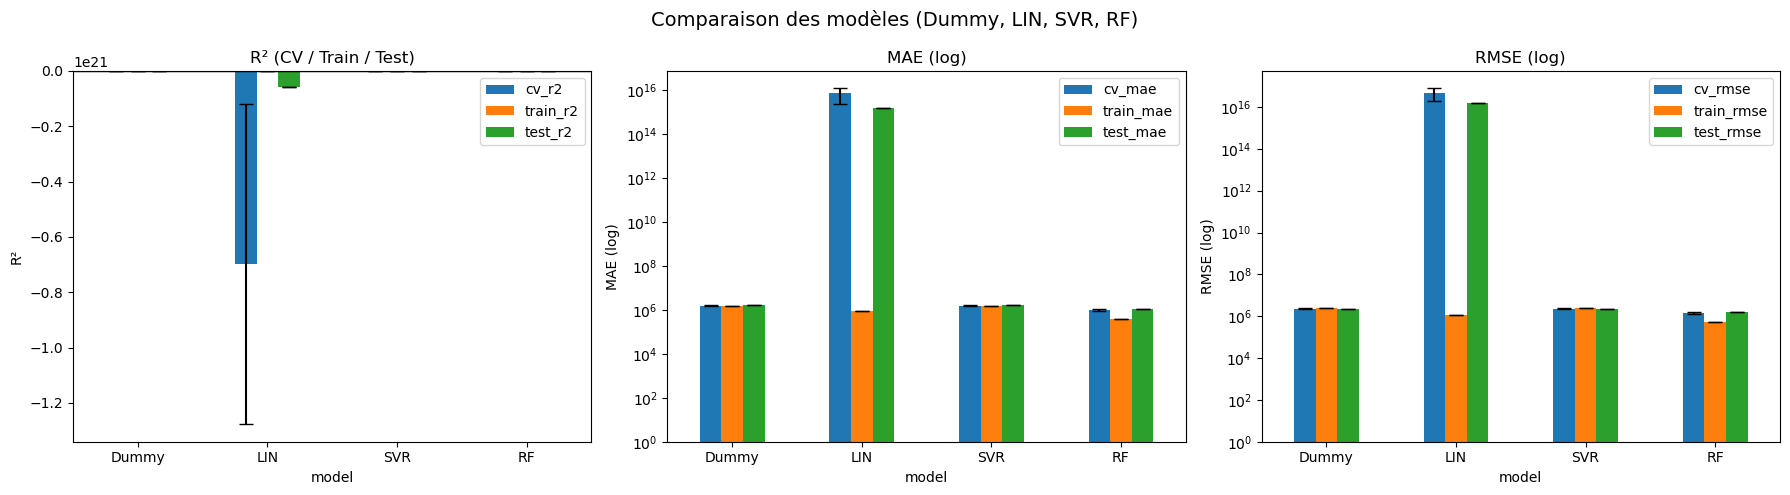

In [249]:
# Données des modèles
data = {
    "model":      ["Dummy", "LIN", "SVR", "RF"],
    "cv_r2":      [-0.124, -698125623175384006656.0, -0.124, 0.570],
    "cv_r2_std":  [0.022,  578322901471103221760.0,  0.022,  0.053],
    "train_r2":   [-0.123, 0.715,                   -0.123, 0.944],
    "test_r2":    [-0.156, -58073119175022395392.0, -0.156, 0.452],
    "cv_mae":     [1595297.94, 7364399356966339.0, 1595189.80, 1014901.44],
    "cv_mae_std": [71095.06,   4896548375944691.0, 71094.41,   87102.19],
    "train_mae":  [1594893.67, 855117.99,          1594750.29, 369948.35],
    "test_mae":   [1632270.78, 1643299812752667.25,1632148.33, 1113843.86],
    "cv_rmse":     [2330765.60, 47477809673884224.0, 2330630.27, 1439033.39],
    "cv_rmse_std": [138626.65,  29072963059835828.0, 138585.72,  121640.60],
    "train_rmse":  [2334513.25, 1176360.26,         2334335.25, 523248.82],
    "test_rmse":   [2296427.92, 16274219244780926.0,2296260.11, 1581255.83],
}

df = pd.DataFrame(data).set_index("model")

yerr_r2 = pd.DataFrame(
    {"cv_r2": df["cv_r2_std"], "train_r2": np.zeros(len(df)), "test_r2": np.zeros(len(df))},
    index=df.index
)
yerr_mae = pd.DataFrame(
    {"cv_mae": df["cv_mae_std"], "train_mae": np.zeros(len(df)), "test_mae": np.zeros(len(df))},
    index=df.index
)
yerr_rmse = pd.DataFrame(
    {"cv_rmse": df["cv_rmse_std"], "train_rmse": np.zeros(len(df)), "test_rmse": np.zeros(len(df))},
    index=df.index
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) R² avec barres d'erreur sur la CV
df[["cv_r2", "train_r2", "test_r2"]].plot(
    kind="bar",
    ax=axes[0],
    yerr=yerr_r2,
    capsize=5
)
axes[0].set_title("R² (CV / Train / Test)")
axes[0].set_ylabel("R²")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].tick_params(axis="x", rotation=0)

# 2) MAE (log) avec barres d'erreur sur la CV
df[["cv_mae", "train_mae", "test_mae"]].plot(
    kind="bar",
    ax=axes[1],
    log=True,
    yerr=yerr_mae,
    capsize=5
)
axes[1].set_title("MAE (log)")
axes[1].set_ylabel("MAE (log)")
axes[1].tick_params(axis="x", rotation=0)

# 3) RMSE (log) avec barres d'erreur sur la CV
df[["cv_rmse", "train_rmse", "test_rmse"]].plot(
    kind="bar",
    ax=axes[2],
    log=True,
    yerr=yerr_rmse,
    capsize=5
)
axes[2].set_title("RMSE (log)")
axes[2].set_ylabel("RMSE (log)")
axes[2].tick_params(axis="x", rotation=0)

fig.suptitle("Comparaison des modèles (Dummy, LIN, SVR, RF)", fontsize=14)
fig.tight_layout()
plt.show()


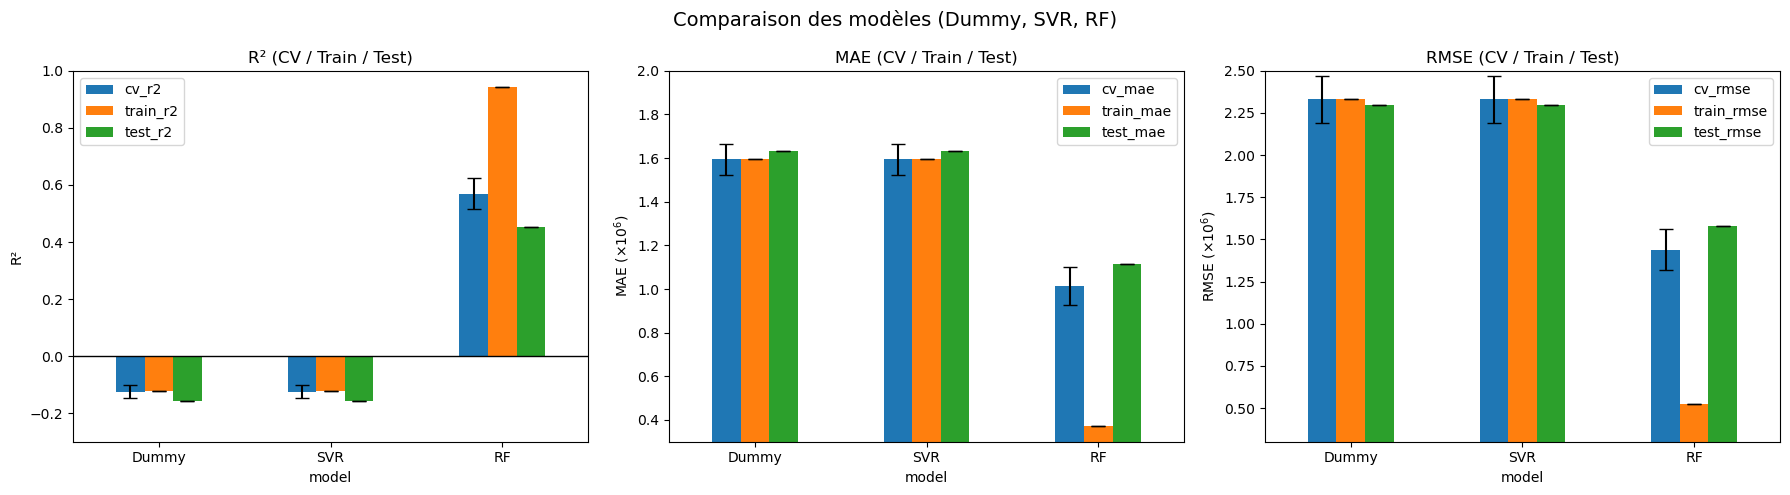

In [248]:
data = {
    "model":      ["Dummy", "SVR", "RF"],
    "cv_r2":      [-0.124, -0.124, 0.570],
    "cv_r2_std":  [0.022,  0.022,  0.053],
    "train_r2":   [-0.123, -0.123, 0.944],
    "test_r2":    [-0.156, -0.156, 0.452],

    "cv_mae":     [1595297.94, 1595189.80, 1014901.44],
    "cv_mae_std": [71095.06,   71094.41,   87102.19],
    "train_mae":  [1594893.67, 1594750.29, 369948.35],
    "test_mae":   [1632270.78, 1632148.33, 1113843.86],

    "cv_rmse":     [2330765.60, 2330630.27, 1439033.39],
    "cv_rmse_std": [138626.65,  138585.72,  121640.60],
    "train_rmse":  [2334513.25, 2334335.25, 523248.82],
    "test_rmse":   [2296427.92, 2296260.11, 1581255.83],
}


df = pd.DataFrame(data).set_index("model")

df_mae_scaled  = df[["cv_mae", "train_mae", "test_mae"]]  / 1e6
df_rmse_scaled = df[["cv_rmse", "train_rmse", "test_rmse"]] / 1e6

yerr_r2 = pd.DataFrame({"cv_r2": df["cv_r2_std"], "train_r2": np.zeros(len(df)), "test_r2": np.zeros(len(df))}, index=df.index)
yerr_mae_scaled  = pd.DataFrame({"cv_mae": df["cv_mae_std"] / 1e6, "train_mae": np.zeros(len(df)), "test_mae": np.zeros(len(df))}, index=df.index)
yerr_rmse_scaled = pd.DataFrame({"cv_rmse": df["cv_rmse_std"] / 1e6, "train_rmse": np.zeros(len(df)), "test_rmse": np.zeros(len(df))}, index=df.index)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df[["cv_r2", "train_r2", "test_r2"]].plot(kind="bar", ax=axes[0], yerr=yerr_r2, capsize=5)
axes[0].set_title("R² (CV / Train / Test)")
axes[0].set_ylabel("R²")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylim(-0.3, 1.0)
axes[0].tick_params(axis="x", rotation=0)

df_mae_scaled.plot(kind="bar", ax=axes[1], yerr=yerr_mae_scaled, capsize=5)
axes[1].set_title("MAE (CV / Train / Test)")
axes[1].set_ylabel(r"MAE ($\times 10^6$)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0.3, 2.0)

df_rmse_scaled.plot(kind="bar", ax=axes[2], yerr=yerr_rmse_scaled, capsize=5)
axes[2].set_title("RMSE (CV / Train / Test)")
axes[2].set_ylabel(r"RMSE ($\times 10^6$)")
axes[2].tick_params(axis="x", rotation=0)
axes[2].set_ylim(0.3, 2.5)

fig.suptitle("Comparaison des modèles (Dummy, SVR, RF)", fontsize=14)
fig.tight_layout()
fig.savefig(
    r"C:\Users\ethan\OpenClassroom\Projet_2\Projet\Anticipez_les_besoins_\Graphs\comparaison_modeles_dummy_svr_rf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()






